In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [94]:
x=np.linspace(-5.0,5.0,100)
y=np.sqrt(10**2-x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [95]:
x1=np.linspace(-5.0,5.0,100)
y1=np.sqrt(5**2-x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

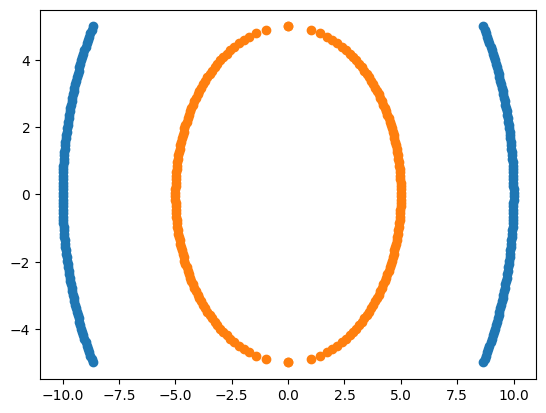

In [96]:
plt.scatter(y,x)
plt.scatter(y1,x1)
plt.show()

In [97]:
df1 = pd.DataFrame(np.vstack([y, x]).T, columns=['x1', 'x2'])
df1['Y'] = 0

df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns=['x1', 'x2'])
df2['Y'] = 1

# Use concat instead of append
df = pd.concat([df1, df2], ignore_index=True)
df.head()


,x1,x2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [98]:
# dividing the independent and independent feature
x=df.iloc[:,:-1]
y=df.iloc[:,-1:]
y

,Y
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,1


In [99]:
from sklearn.model_selection import train_test_split 
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=10)

In [100]:
df['x1sqr']=df['x1']**2
df['x2sqr']=df['x2']**2
df['x1*x2']=df['x1']*df['x2']
df.head()

,x1,x2,Y,x1sqr,x2sqr,x1*x2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [101]:
# independent and dependent
x=df[['x1','x2','x1sqr','x2sqr','x1*x2']]
y=df['Y']

In [102]:
x

,x1,x2,x1sqr,x2sqr,x1*x2
0,8.660254,-5.00000,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,78.877155,21.122845,-40.818009
...,...,...,...,...,...
395,-1.969049,-4.59596,3.877155,21.122845,9.049671
396,-1.714198,-4.69697,2.938476,22.061524,8.051537
397,-1.406908,-4.79798,1.979390,23.020610,6.750316
398,-0.999949,-4.89899,0.999898,24.000102,4.898740


In [103]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=0)

In [104]:
import plotly.express as px
fig=px.scatter_3d(df,x='x1',y='x2',z='x1*x2',color='Y')
fig.show()

In [105]:
import plotly.express as px
fig=px.scatter_3d(df,x='x1sqr',y='x2sqr',z='x1*x2',color='Y')
fig.show()

In [106]:
ytrain

250    1
63     0
312    1
159    0
283    1
      ..
323    1
192    0
117    0
47     0
172    0
Name: Y, Length: 300, dtype: int64

In [107]:
ytrain

250    1
63     0
312    1
159    0
283    1
      ..
323    1
192    0
117    0
47     0
172    0
Name: Y, Length: 300, dtype: int64

In [108]:
print(xtrain.shape, xtest.shape)
print("Train class counts:\n", np.bincount(ytrain))
print("Test class counts:\n", np.bincount(ytest))


(300, 5) (100, 5)
Train class counts:
 [145 155]
Test class counts:
 [55 45]


In [109]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.svm import SVC
svc=SVC(kernel='rbf')
svc.fit(xtrain,ytrain)
y_pred=svc.predict(xtest)
print(confusion_matrix(ytest,y_pred))
print(classification_report(ytest,y_pred))

[[55  0]
 [ 0 45]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [110]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.svm import SVC
svc=SVC(kernel='poly')
svc.fit(xtrain,ytrain)
y_pred=svc.predict(xtest)
print(confusion_matrix(ytest,y_pred))
print(classification_report(ytest,y_pred))

[[55  0]
 [ 0 45]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

